# Stroke Prediction — Machine Learning Assignment
**Course:** Fundamentals of Machine Learning  
**Group Members:**
- Member 1: Karunarathna P.K.A.L. | [ms26901626@my.sliit.lk]
- Member 2: Pandipperuma R.T. | [ms26901008@my.sliit.lk]

**Dataset:** Stroke Prediction Dataset  
**Source:** https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset  
**Algorithms:** Logistic Regression (Member 1) | Random Forest (Member 2)  



## SECTION 1: Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing & model selection
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

# Class imbalance handling
from imblearn.over_sampling import SMOTE

print('All libraries imported successfully.')

All libraries imported successfully.


## SECTION 2: Load Dataset

In [2]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

print('Dataset Shape:', df.shape)
print('\nColumn Names:', list(df.columns))
df.head(10)

Dataset Shape: (5110, 12)

Column Names: ['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


## SECTION 3: Exploratory Data Analysis (EDA)

In [3]:
# Dataset overview
print('Basic Info')
df.info()
print('\nStatistical Summary')
print(df.describe())

Basic Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB

Statistical Summary
                 id          age  hypertension  heart_disease  \
count   5110.000000  5110.000000   5110.000000    5110.00000

In [4]:
# Missing values and class distribution
print('Missing Values')
print(df.isnull().sum())
print('\nTarget Class Distribution')
print(df['stroke'].value_counts())
print(f'\nStroke rate: {df["stroke"].mean()*100:.2f}%')
print('Note: Severe class imbalance — only ~5% are positive stroke cases.')

Missing Values
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Target Class Distribution
stroke
0    4861
1     249
Name: count, dtype: int64

Stroke rate: 4.87%
Note: Severe class imbalance — only ~5% are positive stroke cases.


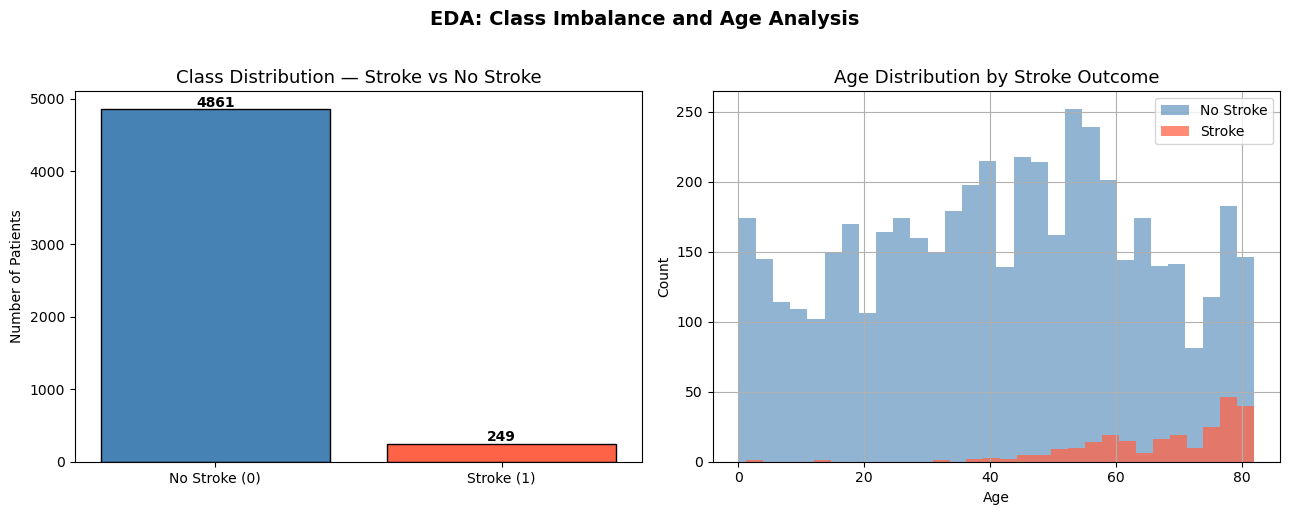

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Class imbalance
counts = df['stroke'].value_counts()
axes[0].bar(['No Stroke (0)', 'Stroke (1)'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution — Stroke vs No Stroke', fontsize=13)
axes[0].set_ylabel('Number of Patients')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Plot 2: Age distribution by stroke outcome
df[df['stroke'] == 0]['age'].hist(bins=30, ax=axes[1], alpha=0.6, color='steelblue', label='No Stroke')
df[df['stroke'] == 1]['age'].hist(bins=30, ax=axes[1], alpha=0.75, color='tomato', label='Stroke')
axes[1].set_title('Age Distribution by Stroke Outcome', fontsize=13)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('EDA: Class Imbalance and Age Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_class_age.png', dpi=150, bbox_inches='tight')
plt.show()

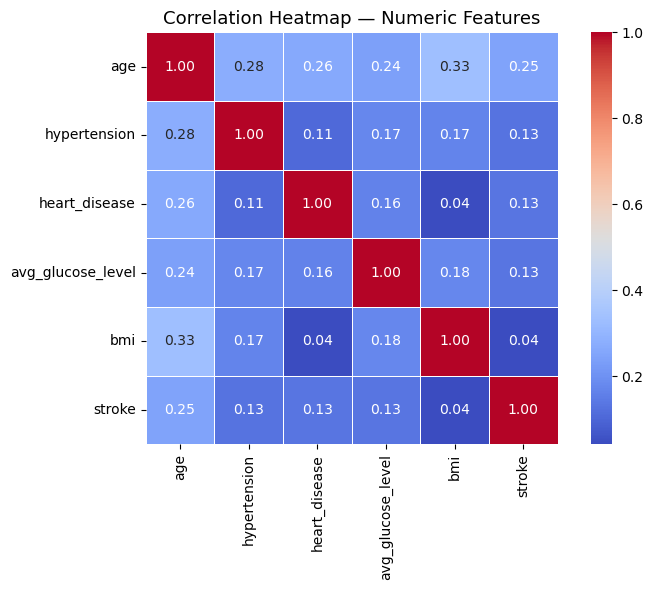

In [6]:
# Correlation heatmap (numeric features only)
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['id'])
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Numeric Features', fontsize=13)
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## SECTION 4: Data Preprocessing

In [7]:
# Step 1: Drop 'id' — not a predictive feature
df = df.drop(columns=['id'])

# Step 2: Remove the single 'Other' gender row (too rare, causes encoding issues)
df = df[df['gender'] != 'Other']
print(f'Shape after removing "Other" gender: {df.shape}')

# Step 3: Impute missing 'bmi' values with the median (robust to outliers)
bmi_median = df['bmi'].median()
df['bmi'].fillna(bmi_median, inplace=True)
print(f'Missing BMI values filled with median: {bmi_median:.2f}')
print(f'Remaining missing values: {df.isnull().sum().sum()}')

Shape after removing "Other" gender: (5109, 11)
Missing BMI values filled with median: 28.10
Remaining missing values: 0


In [8]:
# Step 4: Label encode binary categorical columns
le = LabelEncoder()
df['gender']         = le.fit_transform(df['gender'])          # Female=0, Male=1
df['ever_married']   = le.fit_transform(df['ever_married'])    # No=0, Yes=1
df['Residence_type'] = le.fit_transform(df['Residence_type'])  # Rural=0, Urban=1

# Step 5: One-hot encode multi-class categorical columns
df = pd.get_dummies(df, columns=['work_type', 'smoking_status'], drop_first=True)

print(f'Shape after encoding: {df.shape}')
print('Final columns:', list(df.columns))

Shape after encoding: (5109, 16)
Final columns: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'Residence_type', 'avg_glucose_level', 'bmi', 'stroke', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']


In [9]:
# Step 6: Separate features and target
X = df.drop(columns=['stroke'])
y = df['stroke']

# Step 7: Stratified 80/20 train-test split (preserves class ratio in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train set: {X_train.shape} | Test set: {X_test.shape}')
print(f'Train class dist: {y_train.value_counts().to_dict()}')
print(f'Test  class dist: {y_test.value_counts().to_dict()}')

Train set: (4087, 15) | Test set: (1022, 15)
Train class dist: {0: 3888, 1: 199}
Test  class dist: {0: 972, 1: 50}


In [10]:
# Step 8: Apply SMOTE ONLY on training data to fix class imbalance
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'After SMOTE — Train shape: {X_train_sm.shape}')
print(f'After SMOTE — Class dist: {pd.Series(y_train_sm).value_counts().to_dict()}')
print('Class imbalance resolved: both classes now have equal representation.')

After SMOTE — Train shape: (7776, 15)
After SMOTE — Class dist: {0: 3888, 1: 3888}
Class imbalance resolved: both classes now have equal representation.
